In [1]:
# ===================== 0. IMPORT THƯ VIỆN =====================
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from collections import Counter
from PIL import Image
import cv2

c:\Users\letra\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ===================== 1. CẤU HÌNH CHUNG =====================
train_data_dir = r"E:\archive\SkinDisease\SkinDisease\train"
validation_data_dir = r"E:\archive\SkinDisease\SkinDisease\test"

TRAIN_DIR = train_data_dir
VAL_DIR   = validation_data_dir

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS     = 100
CHECKPOINT_PATH = "densenet121_pretrained_fulloption.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

Using device: cuda


In [3]:
# ===================== 2. DATA AUGMENTATION =====================
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.02),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.2), ratio=(0.3, 3.3)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

📂 Số lớp: 22
Lớp: ['Acne', 'Actinic_Keratosis', 'Benign_tumors', 'Bullous', 'Candidiasis', 'DrugEruption', 'Eczema', 'Infestations_Bites', 'Lichen', 'Lupus', 'Moles', 'Psoriasis', 'Rosacea', 'Seborrh_Keratoses', 'SkinCancer', 'Sun_Sunlight_Damage', 'Tinea', 'Unknown_Normal', 'Vascular_Tumors', 'Vasculitis', 'Vitiligo', 'Warts']
🖼️ Số ảnh train: 13898, val: 1333


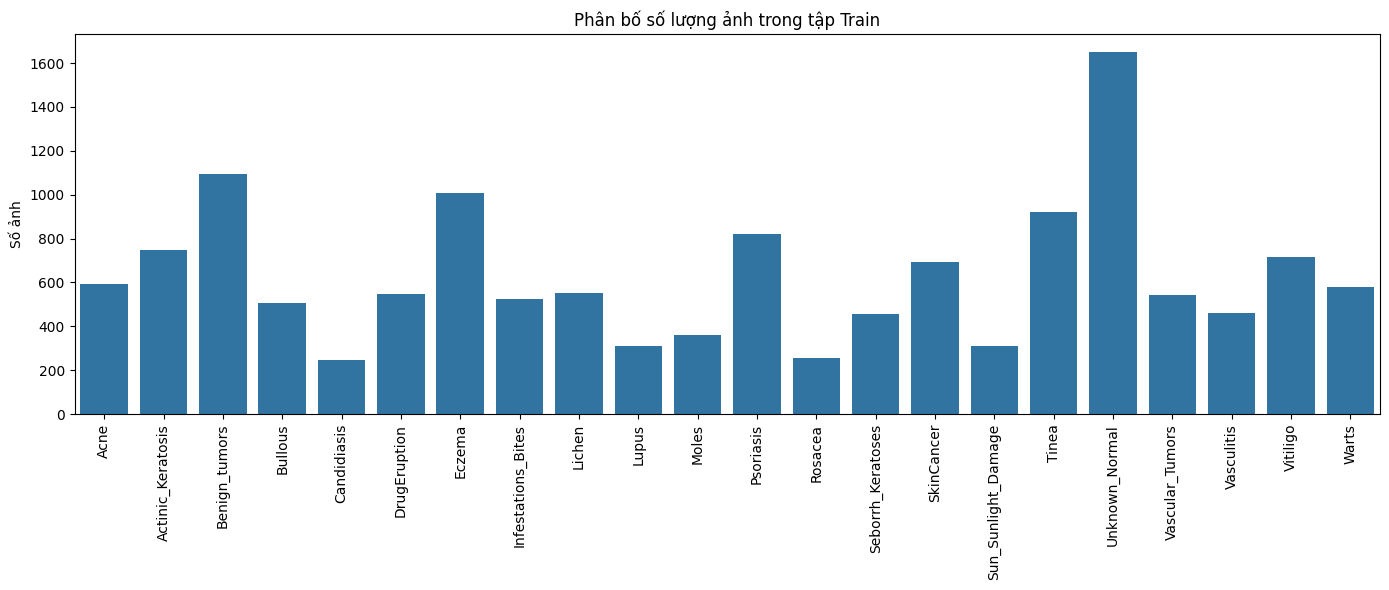

⚖️ Class weights: [1.06530737 0.84455518 0.57797555 1.25342713 2.54728739 1.15489447
 0.62547255 1.2055864  1.14236397 2.0312774  1.74993704 0.77039911
 2.48711525 1.38841159 0.91158337 2.0247669  0.68442825 0.38263311
 1.16340198 1.37034116 0.88477209 1.08918495]


In [4]:
# ===================== 3. DATASETS & LOADERS =====================
train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_ds   = datasets.ImageFolder(VAL_DIR,   transform=val_transform)

class_names = train_ds.classes
num_classes = len(class_names)

print(f"📂 Số lớp: {num_classes}")
print("Lớp:", class_names)
print(f"🖼️ Số ảnh train: {len(train_ds)}, val: {len(val_ds)}")

# --- phân bố nhãn train ---
train_labels = [label for _, label in train_ds.samples]
label_counts = Counter(train_labels)

plt.figure(figsize=(14, 6))
sns.barplot(x=[class_names[i] for i in label_counts.keys()],
            y=list(label_counts.values()))
plt.xticks(rotation=90)
plt.ylabel("Số ảnh")
plt.title("Phân bố số lượng ảnh trong tập Train")
plt.tight_layout()
plt.show()

# --- class weights cho CrossEntropy ---
class_weights_np = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float).to(device)
print("⚖️ Class weights:", class_weights_np)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4
)

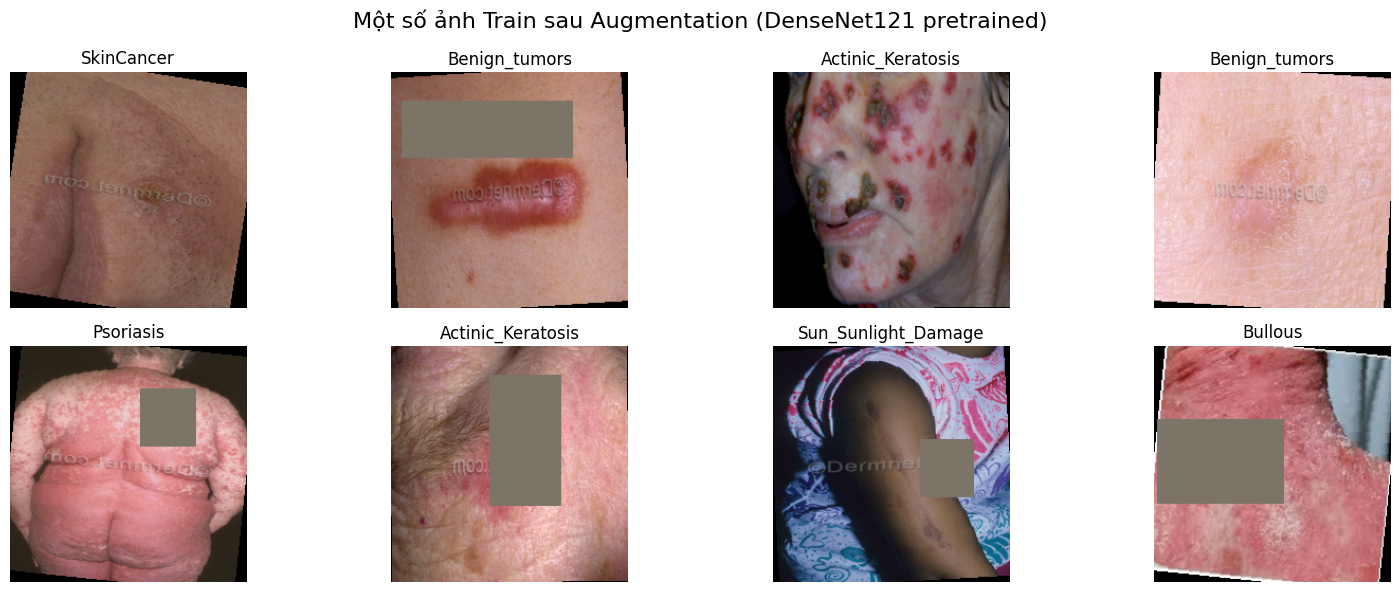

In [5]:
# ===================== 4. XEM ẢNH TRAIN SAU AUGMENT =====================
def unnormalize_imagenet(t):
    t = t.clone().cpu().numpy()
    for c in range(3):
        t[c] = t[c] * IMAGENET_STD[c] + IMAGENET_MEAN[c]
    return np.clip(t, 0, 1)

def show_train_samples(dataset, class_names, n=8):
    n = min(n, len(dataset))
    idxs = random.sample(range(len(dataset)), n)
    plt.figure(figsize=(16, 6))
    for i, idx in enumerate(idxs):
        img, lbl = dataset[idx]
        img_disp = unnormalize_imagenet(img).transpose(1, 2, 0)

        plt.subplot(2, (n+1)//2, i+1)
        plt.imshow(img_disp)
        plt.title(class_names[lbl])
        plt.axis("off")
    plt.suptitle("Một số ảnh Train sau Augmentation (DenseNet121 pretrained)", fontsize=16)
    plt.tight_layout()
    plt.show()

show_train_samples(train_ds, class_names)

In [6]:
# ===================== 5. KHỞI TẠO DENSENET121 (PRETRAINED TRUE) =====================
try:
    weights = models.DenseNet121_Weights.IMAGENET1K_V1
    densenet = models.densenet121(weights=weights)
except AttributeError:
    densenet = models.densenet121(pretrained=True)

# thay classifier cuối cho đúng số lớp
in_features = densenet.classifier.in_features
densenet.classifier = nn.Linear(in_features, num_classes)

model = densenet.to(device)
print("✅ DenseNet121 (pretrained=True) initialized.")

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=3,
    verbose=True
)

✅ DenseNet121 (pretrained=True) initialized.


c:\Users\letra\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\optim\lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [7]:
# ===================== 6. TRAINING LOOP (CÓ VAL, SAVE BEST) =====================
best_val_acc = 0.0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, EPOCHS+1):
    # ------ TRAIN ------
    model.train()
    running_loss = 0.0
    running_correct = 0
    running_total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} - Train"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        running_correct += preds.eq(labels).sum().item()
        running_total += labels.size(0)

    train_loss = running_loss / running_total
    train_acc = running_correct / running_total
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ------ VAL ------
    model.eval()
    val_loss_sum = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} - Val", leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            val_correct += preds.eq(labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct / val_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    scheduler.step(val_acc)

    print(f"[Epoch {epoch}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print("📌 Best model saved:", CHECKPOINT_PATH)

# load best
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
model.eval()
print(f"✅ Training complete. Best val acc: {best_val_acc:.4f}")

Epoch 1/100 - Train: 100%|██████████| 435/435 [01:53<00:00,  3.84it/s]


[Epoch 1/100] Train Loss: 2.1042, Acc: 0.3970 | Val Loss: 1.5004, Acc: 0.5311
📌 Best model saved: densenet121_pretrained_fulloption.pth


Epoch 2/100 - Train: 100%|██████████| 435/435 [01:59<00:00,  3.65it/s]


[Epoch 2/100] Train Loss: 1.4761, Acc: 0.5660 | Val Loss: 1.2660, Acc: 0.5904
📌 Best model saved: densenet121_pretrained_fulloption.pth


Epoch 3/100 - Train: 100%|██████████| 435/435 [01:48<00:00,  4.01it/s]


...

Epoch 99/100 - Train: 100%|██████████| 435/435 [01:57<00:00,  3.69it/s]


[Epoch 99/100] Train Loss: 0.0249, Acc: 0.9935 | Val Loss: 0.8777, Acc: 0.8080
📌 Best model saved: densenet121_pretrained_fulloption.pth


Epoch 100/100 - Train: 100%|██████████| 435/435 [01:53<00:00,  3.83it/s]


[Epoch 100/100] Train Loss: 0.0226, Acc: 0.9934 | Val Loss: 0.8885, Acc: 0.8020
✅ Training complete. Best val acc: 0.8080


C:\Users\letra\AppData\Local\Temp\ipykernel_26176\1004771863.py:68: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(CHECKPOINT_PATH, map_locat

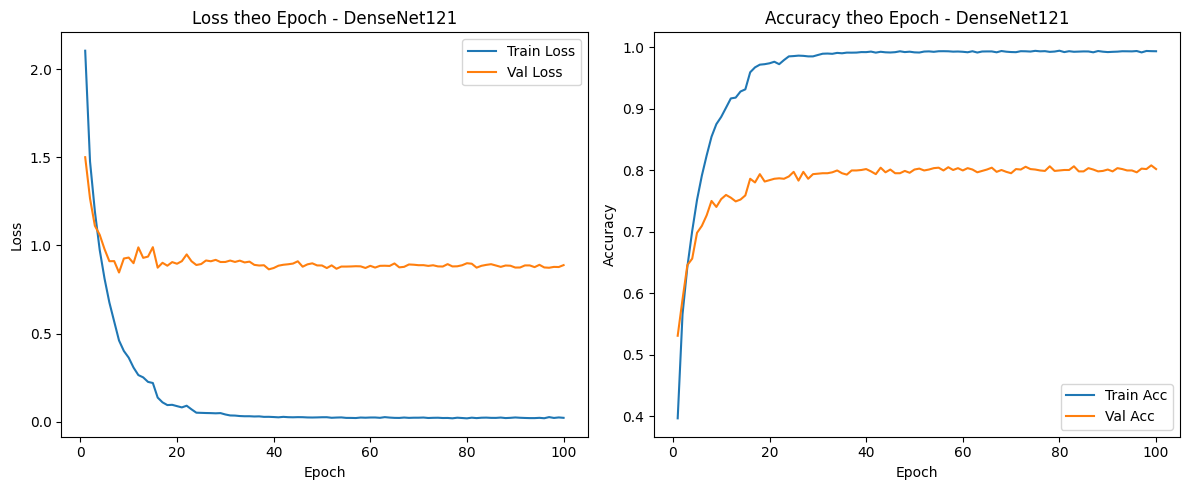

In [8]:
# ===================== 7. LOSS & ACCURACY CURVES =====================
epochs_range = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Loss theo Epoch - DenseNet121")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs_range, train_accs, label="Train Acc")
plt.plot(epochs_range, val_accs, label="Val Acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Accuracy theo Epoch - DenseNet121")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# ===================== 8. REPORT + CONFUSION MATRIX =====================
y_true = []
y_pred = []
y_prob = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)

        _, preds = probs.max(1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("\n📊 Classification Report (Validation) - DenseNet121:")
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm,
            annot=False,
            fmt='d',
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - DenseNet121 (Pretrained)")
plt.tight_layout()
plt.show()

In [ ]:
# ===================== 9. ROC CURVE PER CLASS =====================
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(12,10))
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=1,
             label=f"{class_names[i]} (AUC={roc_auc[i]:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Per-Class ROC Curves - DenseNet121 (Pretrained)")
plt.legend(fontsize="small", loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()